<a href="https://www.kaggle.com/code/omborse771924/college-major-career-analysis-94-accuracy?scriptVersionId=343510119" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/college-major-career-analytics-dataset/college_major_career_outcomes_2026.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/srisyra02/college-major-career-analytics-dataset/college_major_career_outcomes_2026.csv')

In [3]:
df.info

<bound method DataFrame.info of                  program_id    unitid  opeid6  \
0       opeid031505-51.07-1       NaN   31505   
1       opeid031505-51.35-1       NaN   31505   
2       opeid031505-52.04-1       NaN   31505   
3            493868-12.04-1  493868.0   42833   
4            177834-13.06-5  177834.0    2477   
...                     ...       ...     ...   
227975       496520-51.35-1  496520.0   42955   
227976       495101-51.35-1  495101.0   42753   
227977       496423-12.04-1  496423.0   43003   
227978       496423-51.35-1  496423.0   43003   
227979  opeid039163-12.04-1       NaN   39163   

                                  institution_name  institution_control  \
0                            A - Technical College  Private, for-profit   
1                            A - Technical College  Private, for-profit   
2                            A - Technical College  Private, for-profit   
3                 A Better U Beauty Barber Academy  Private, for-profit   
4   

In [4]:
df.head()

,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,...,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
0,opeid031505-51.07-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,1.0,0.053,0.368,1.0,31.95,OpenAI ChatGPT,reported,reported,reported,reported
1,opeid031505-51.35-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.000,0.0,5.50,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
2,opeid031505-52.04-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.167,0.0,18.11,NaN,reported,privacy_suppressed,privacy_suppressed,privacy_suppressed
3,493868-12.04-1,493868.0,42833,A Better U Beauty Barber Academy,"Private, for-profit",1,Albuquerque,NM,Southwest,35.110630,...,0.0,0.000,0.000,0.0,5.12,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
4,177834-13.06-5,177834.0,2477,A T Still University of Health Sciences,"Private, nonprofit",1,Kirksville,MO,Plains,40.193648,...,2.0,0.333,0.333,2.0,35.00,Angoss KnowledgeSEEKER; SAS Enterprise Miner; ...,privacy_suppressed,not_available,not_available,not_available


In [5]:
df.tail()

,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,...,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
227975,496520-51.35-1,496520.0,42955,Zen Shiatsu Chicago,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,5.50,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,not_available
227976,495101-51.35-1,495101.0,42753,Zion Massage College,"Private, for-profit",1,St. George,UT,Rocky Mountains,37.097894,...,0.0,0.0,0.0,0.0,5.50,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
227977,496423-12.04-1,496423.0,43003,Zorganics Institute of Beauty and Wellness,"Private, for-profit",1,Bellingham,WA,Far West,48.791271,...,0.0,0.0,0.0,0.0,5.12,NaN,privacy_suppressed,not_available,not_available,not_available
227978,496423-51.35-1,496423.0,43003,Zorganics Institute of Beauty and Wellness,"Private, for-profit",1,Bellingham,WA,Far West,48.791271,...,0.0,0.0,0.0,0.0,5.50,NaN,privacy_suppressed,not_available,not_available,not_available
227979,opeid039163-12.04-1,NaN,39163,eClips School of Cosmetology and Barbering,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,5.12,NaN,reported,privacy_suppressed,reported,privacy_suppressed


In [6]:
df.describe

<bound method NDFrame.describe of                  program_id    unitid  opeid6  \
0       opeid031505-51.07-1       NaN   31505   
1       opeid031505-51.35-1       NaN   31505   
2       opeid031505-52.04-1       NaN   31505   
3            493868-12.04-1  493868.0   42833   
4            177834-13.06-5  177834.0    2477   
...                     ...       ...     ...   
227975       496520-51.35-1  496520.0   42955   
227976       495101-51.35-1  495101.0   42753   
227977       496423-12.04-1  496423.0   43003   
227978       496423-51.35-1  496423.0   43003   
227979  opeid039163-12.04-1       NaN   39163   

                                  institution_name  institution_control  \
0                            A - Technical College  Private, for-profit   
1                            A - Technical College  Private, for-profit   
2                            A - Technical College  Private, for-profit   
3                 A Better U Beauty Barber Academy  Private, for-profit   
4 

In [7]:
df.isnull()

,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,...,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
0,False,True,False,False,False,False,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,True,True,True,True,...,False,False,False,False,False,True,False,False,False,False
2,False,True,False,False,False,False,True,True,True,True,...,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227975,False,False,False,False,False,False,True,True,True,True,...,False,False,False,False,False,True,False,False,False,False
227976,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
227977,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
227978,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [8]:
df.isnull().sum()

program_id                  0
unitid                   7020
opeid6                      0
institution_name            0
institution_control         0
                        ...  
ai_tool_examples       153550
earnings_4yr_status         0
earnings_1yr_status         0
earnings_5yr_status         0
debt_status                 0
Length: 72, dtype: int64

In [9]:
# ==========================================================
# HANDLE NULL VALUES - COMPLETE CODE
# ==========================================================

import pandas as pd
import numpy as np

# Make a copy
data = df.copy()

# ==========================================================
# 1. CHECK INITIAL NULL VALUES
# ==========================================================

print("=" * 70)
print("INITIAL NULL VALUES")
print("=" * 70)

null_counts = data.isnull().sum()

print(
    null_counts[null_counts > 0]
    .sort_values(ascending=False)
)

# ==========================================================
# 2. CALCULATE NULL PERCENTAGE
# ==========================================================

null_percentage = (
    data.isnull().sum() / len(data)
) * 100

null_summary = pd.DataFrame({
    "Null_Count": data.isnull().sum(),
    "Null_Percentage": null_percentage
})

print("\n" + "=" * 70)
print("COLUMNS WITH MISSING VALUES")
print("=" * 70)

print(
    null_summary[
        null_summary["Null_Count"] > 0
    ]
    .sort_values(
        by="Null_Percentage",
        ascending=False
    )
)

# ==========================================================
# 3. DROP COLUMNS WITH MORE THAN 50% NULL VALUES
# ==========================================================

threshold = 50

columns_to_drop = null_percentage[
    null_percentage > threshold
].index.tolist()

print("\n" + "=" * 70)
print("COLUMNS DROPPED (>50% NULL)")
print("=" * 70)

print(columns_to_drop)

data.drop(
    columns=columns_to_drop,
    inplace=True
)

# ==========================================================
# 4. IDENTIFY NUMERICAL COLUMNS
# ==========================================================

numeric_columns = data.select_dtypes(
    include=np.number
).columns.tolist()

print("\n" + "=" * 70)
print("NUMERICAL COLUMNS")
print("=" * 70)

print(numeric_columns)

# ==========================================================
# 5. IDENTIFY CATEGORICAL / TEXT COLUMNS
# ==========================================================

categorical_columns = data.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\n" + "=" * 70)
print("CATEGORICAL / TEXT COLUMNS")
print("=" * 70)

print(categorical_columns)

# ==========================================================
# 6. HANDLE NUMERICAL NULL VALUES
# ==========================================================

for col in numeric_columns:

    median_value = data[col].median()

    data[col] = data[col].fillna(
        median_value
    )

# ==========================================================
# 7. HANDLE CATEGORICAL NULL VALUES
# ==========================================================

for col in categorical_columns:

    if data[col].notna().any():

        mode_value = data[col].mode()

        if len(mode_value) > 0:

            data[col] = data[col].fillna(
                mode_value[0]
            )

        else:

            data[col] = data[col].fillna(
                "Unknown"
            )

    else:

        data[col] = data[col].fillna(
            "Unknown"
        )

# ==========================================================
# 8. FINAL NULL CHECK
# ==========================================================

print("\n" + "=" * 70)
print("NULL VALUES AFTER HANDLING")
print("=" * 70)

final_nulls = data.isnull().sum()

print(
    final_nulls[
        final_nulls > 0
    ]
)

# ==========================================================
# 9. TOTAL REMAINING NULL VALUES
# ==========================================================

total_nulls = data.isnull().sum().sum()

print("\nTotal remaining null values:")
print(total_nulls)

# ==========================================================
# 10. DATASET INFORMATION
# ==========================================================

print("\n" + "=" * 70)
print("DATASET AFTER NULL HANDLING")
print("=" * 70)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

# ==========================================================
# 11. SAVE CLEAN DATASET TO df
# ==========================================================

df = data.copy()

print("\nData cleaning completed successfully!")

INITIAL NULL VALUES
count_working_in_state_5yr              188983
pct_working_in_state_5yr                188983
earnings_trajectory_category            188859
earnings_growth_pct_1yr_to_5yr          188859
debt_to_earnings_1yr                    184672
payment_to_income_pct_1yr               184672
debt_to_earnings_4yr                    184605
count_above_hs_threshold_5yr            184144
pct_above_hs_threshold_5yr              184144
median_debt_usd                         181307
median_monthly_payment_usd              181307
earnings_cohort_size_5yr                177468
median_earnings_5yr_usd                 177468
pct_working_5yr                         177468
median_earnings_1yr_usd                 175754
earnings_cohort_size_1yr                175754
debt_borrower_count                     169879
earnings_vs_national_pct                169872
median_earnings_4yr_usd                 169868
earnings_cohort_size_4yr                169868
ai_tool_examples                        

In [10]:
# ==========================================================
# HANDLE NULL VALUES - UNIVERSITY DATASET
# ==========================================================

import pandas as pd
import numpy as np

# Make a copy
data = df.copy()

# ==========================================================
# 1. INITIAL NULL VALUES
# ==========================================================

print("=" * 70)
print("INITIAL NULL VALUES")
print("=" * 70)

initial_nulls = data.isnull().sum()

print(
    initial_nulls[initial_nulls > 0]
    .sort_values(ascending=False)
)

# ==========================================================
# 2. NULL PERCENTAGE
# ==========================================================

null_percentage = (
    data.isnull().sum() / len(data)
) * 100

null_summary = pd.DataFrame({
    "Null_Count": data.isnull().sum(),
    "Null_Percentage": null_percentage
})

print("\n" + "=" * 70)
print("NULL PERCENTAGE")
print("=" * 70)

print(
    null_summary[
        null_summary["Null_Count"] > 0
    ]
    .sort_values(
        by="Null_Percentage",
        ascending=False
    )
)

# ==========================================================
# 3. DROP COLUMNS WITH MORE THAN 70% NULL VALUES
# ==========================================================

drop_threshold = 70

columns_to_drop = null_percentage[
    null_percentage > drop_threshold
].index.tolist()

print("\n" + "=" * 70)
print("COLUMNS DROPPED (>70% NULL)")
print("=" * 70)

if len(columns_to_drop) > 0:
    print(columns_to_drop)
else:
    print("No columns dropped.")

data.drop(
    columns=columns_to_drop,
    inplace=True
)

# ==========================================================
# 4. NUMERICAL COLUMNS
# ==========================================================

numeric_columns = data.select_dtypes(
    include=np.number
).columns.tolist()

print("\n" + "=" * 70)
print("NUMERICAL COLUMNS")
print("=" * 70)

print(numeric_columns)

# ==========================================================
# 5. CATEGORICAL / TEXT COLUMNS
# ==========================================================

categorical_columns = data.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\n" + "=" * 70)
print("CATEGORICAL / TEXT COLUMNS")
print("=" * 70)

print(categorical_columns)

# ==========================================================
# 6. HANDLE NUMERICAL NULL VALUES
# ==========================================================

for col in numeric_columns:

    if data[col].isnull().sum() > 0:

        median_value = data[col].median()

        data[col] = data[col].fillna(
            median_value
        )

# ==========================================================
# 7. HANDLE CATEGORICAL NULL VALUES
# ==========================================================

for col in categorical_columns:

    if data[col].isnull().sum() > 0:

        mode_values = data[col].mode()

        if len(mode_values) > 0:

            data[col] = data[col].fillna(
                mode_values.iloc[0]
            )

        else:

            data[col] = data[col].fillna(
                "Unknown"
            )

# ==========================================================
# 8. FINAL NULL CHECK
# ==========================================================

print("\n" + "=" * 70)
print("FINAL NULL VALUES")
print("=" * 70)

final_nulls = data.isnull().sum()

remaining_nulls = final_nulls[
    final_nulls > 0
]

if len(remaining_nulls) == 0:

    print("No missing values remaining.")

else:

    print(remaining_nulls)

# ==========================================================
# 9. TOTAL NULL VALUES
# ==========================================================

total_remaining_nulls = (
    data.isnull().sum().sum()
)

print("\nTotal remaining null values:")
print(total_remaining_nulls)

# ==========================================================
# 10. DATASET SHAPE
# ==========================================================

print("\n" + "=" * 70)
print("DATASET AFTER NULL HANDLING")
print("=" * 70)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

# ==========================================================
# 11. UPDATE DF
# ==========================================================

df = data.copy()

print("\nCleaning completed successfully!")

INITIAL NULL VALUES
Series([], dtype: int64)

NULL PERCENTAGE
Empty DataFrame
Columns: [Null_Count, Null_Percentage]
Index: []

COLUMNS DROPPED (>70% NULL)
No columns dropped.

NUMERICAL COLUMNS
['unitid', 'opeid6', 'is_main_campus', 'institution_latitude', 'institution_longitude', 'institution_is_hbcu', 'institution_admission_rate', 'institution_undergrad_enrollment', 'institution_tuition_in_state_usd', 'institution_tuition_out_state_usd', 'cip_code_4digit', 'cip_family_code', 'credential_level', 'awards_year1', 'awards_year2', 'outcomes_shared_across_campuses', 'national_median_earnings_4yr_usd', 'national_p25_earnings_4yr_usd', 'national_p75_earnings_4yr_usd', 'not_working_count_5yr', 'linked_occupations_count', 'linked_occupations_in_bls', 'occupation_employment_2024_thousands', 'occupation_growth_pct_2024_34', 'occupation_growth_pct_max', 'occupation_annual_openings_thousands', 'occupation_median_wage_2024_usd', 'linked_occupations_in_onet', 'occupations_using_ai_software', 'ai_so

In [11]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
227975    False
227976    False
227977    False
227978    False
227979    False
Length: 227980, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['program_id', 'unitid', 'opeid6', 'institution_name',
       'institution_control', 'is_main_campus', 'institution_city',
       'institution_state', 'institution_region', 'institution_latitude',
       'institution_longitude', 'institution_is_hbcu',
       'institution_admission_rate', 'institution_undergrad_enrollment',
       'institution_tuition_in_state_usd', 'institution_tuition_out_state_usd',
       'cip_code_4digit', 'cip_title', 'cip_family_code', 'cip_family_title',
       'credential_level', 'credential_name', 'distance_education',
       'awards_year1', 'awards_year2', 'outcomes_shared_across_campuses',
       'national_median_earnings_4yr_usd', 'national_p25_earnings_4yr_usd',
       'national_p75_earnings_4yr_usd', 'not_working_count_5yr',
       'linked_occupations_count', 'linked_occupations_in_bls',
       'largest_linked_occupation', 'largest_linked_occupation_soc',
       'occupation_typical_entry_education',
       'occupation_employment_2024_thousands', 'oc

## EDA

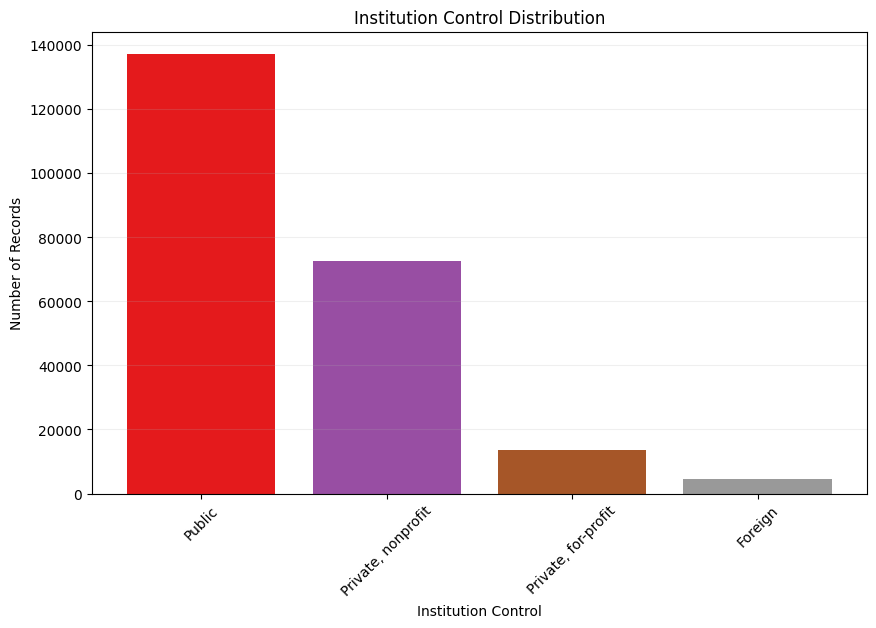

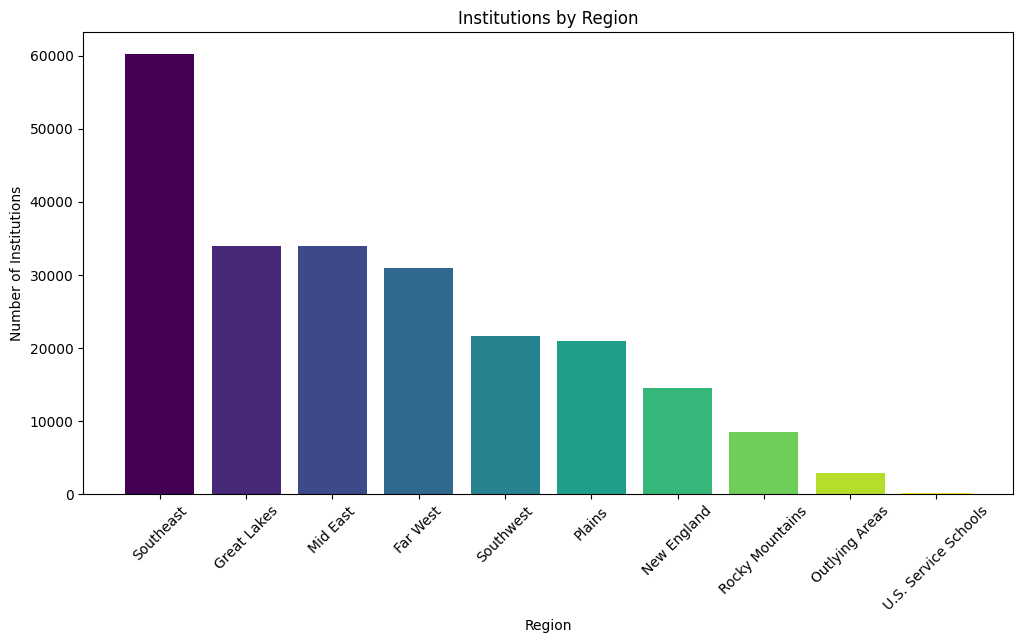

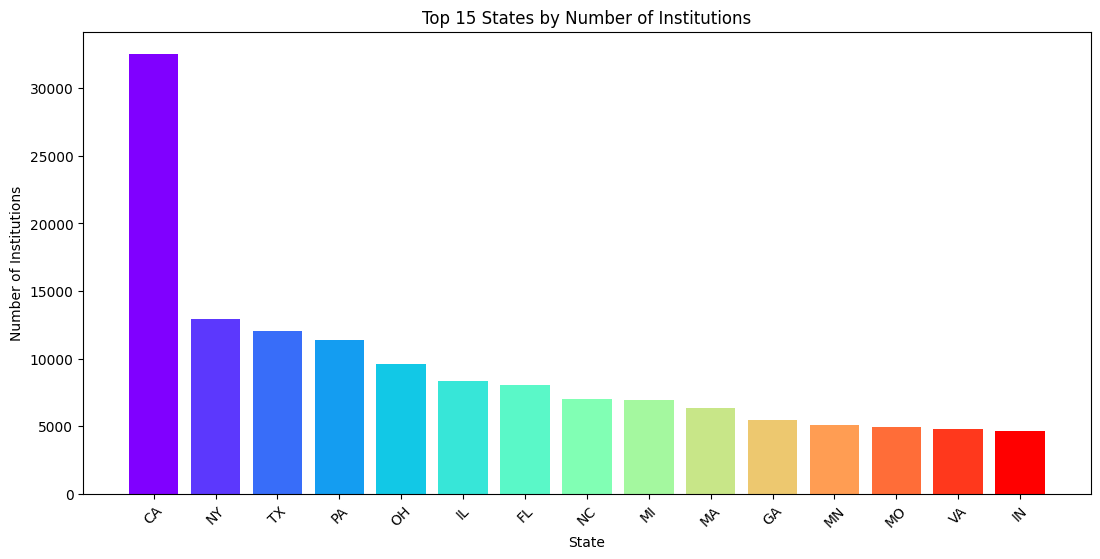

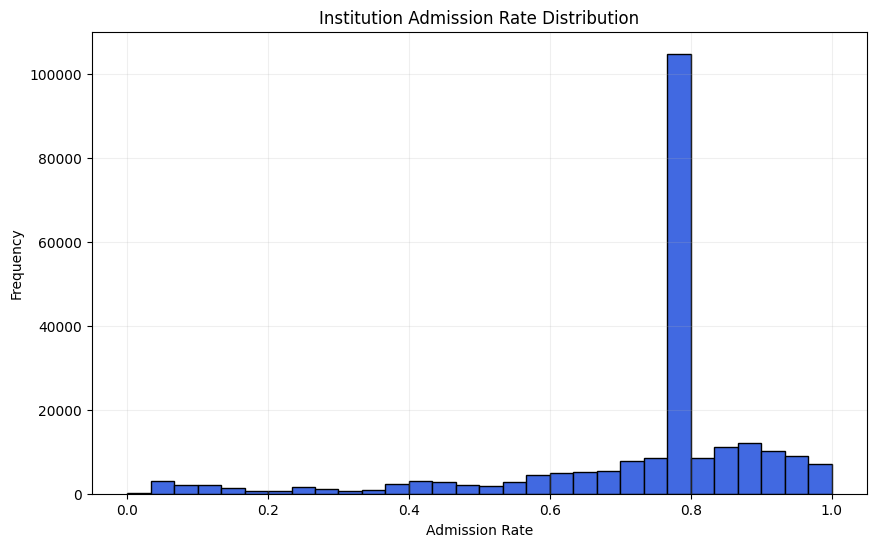

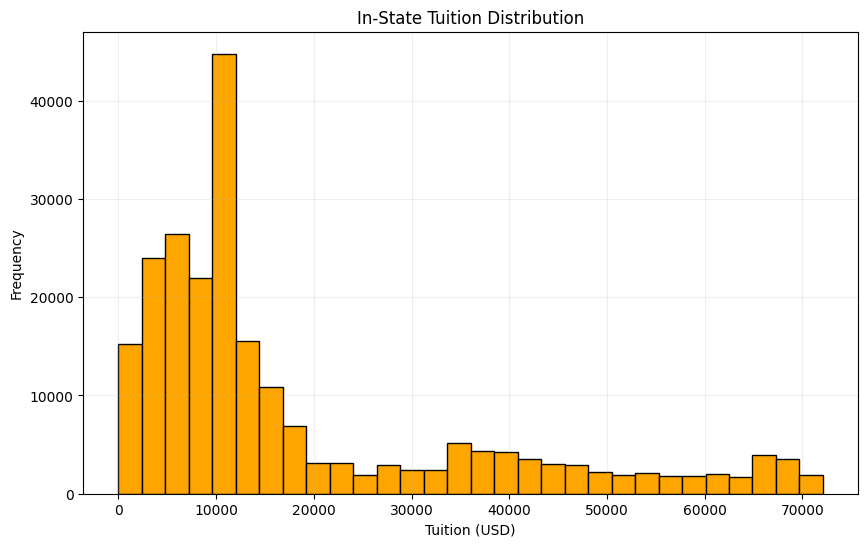

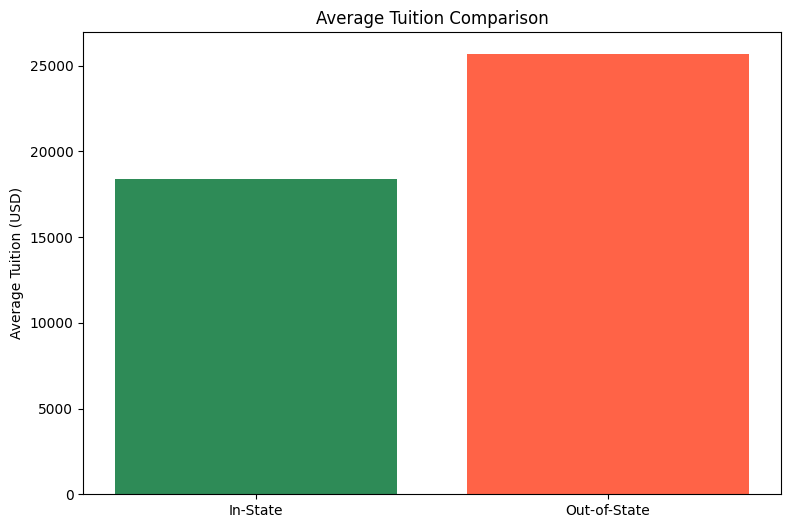

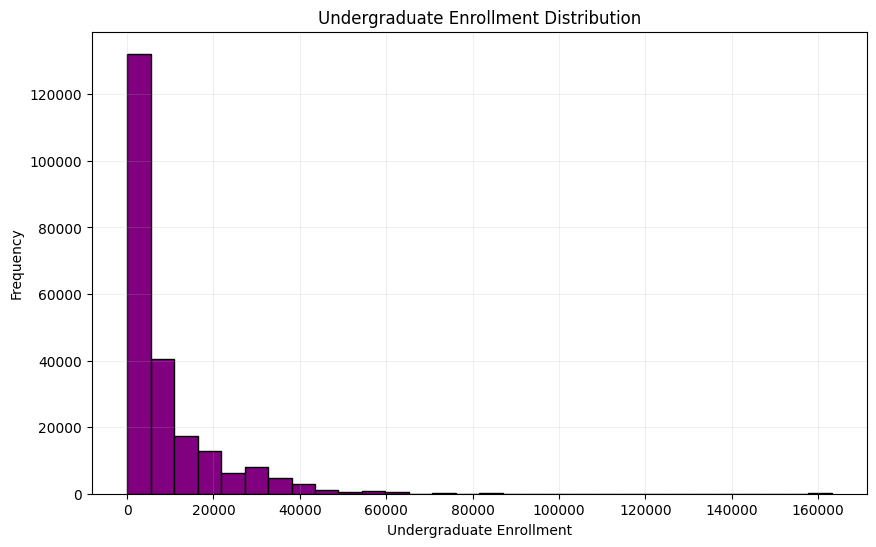

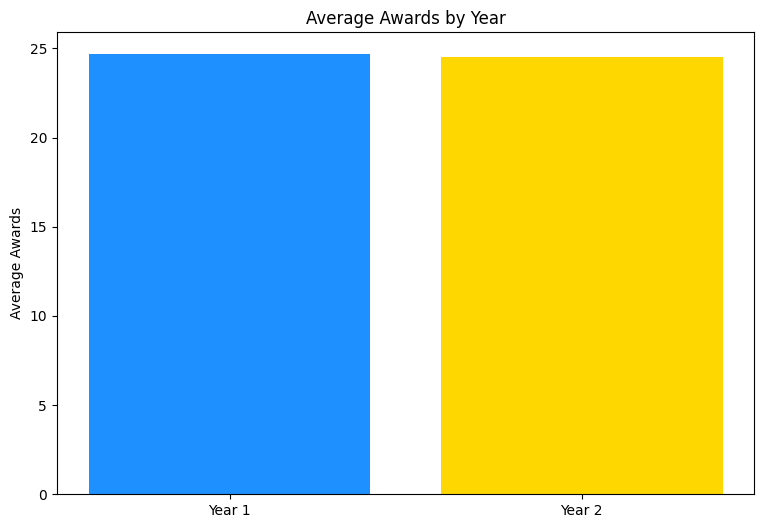

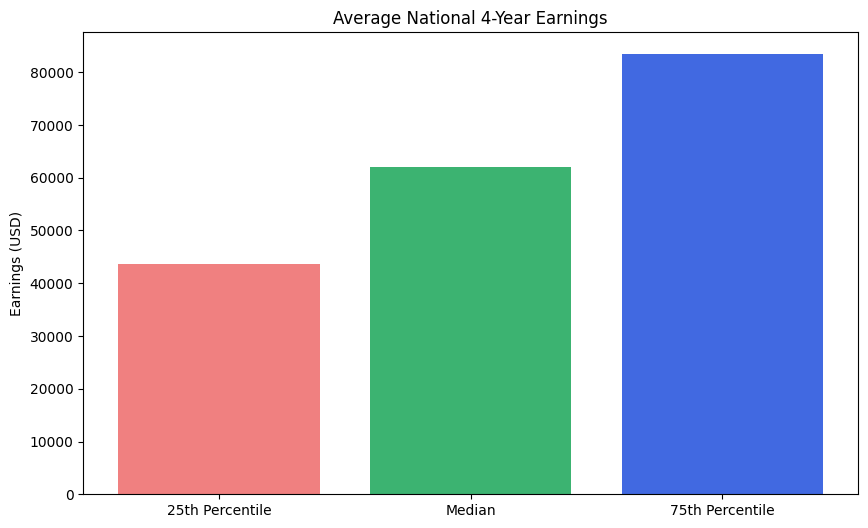

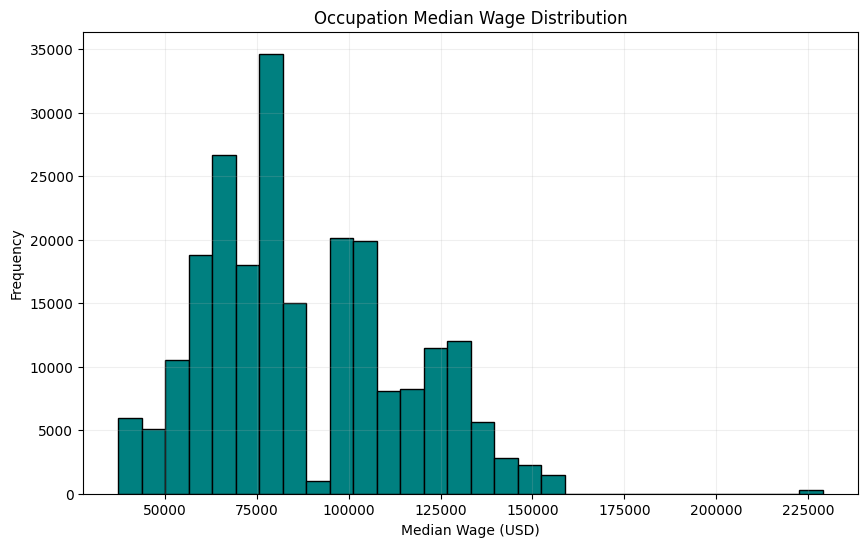

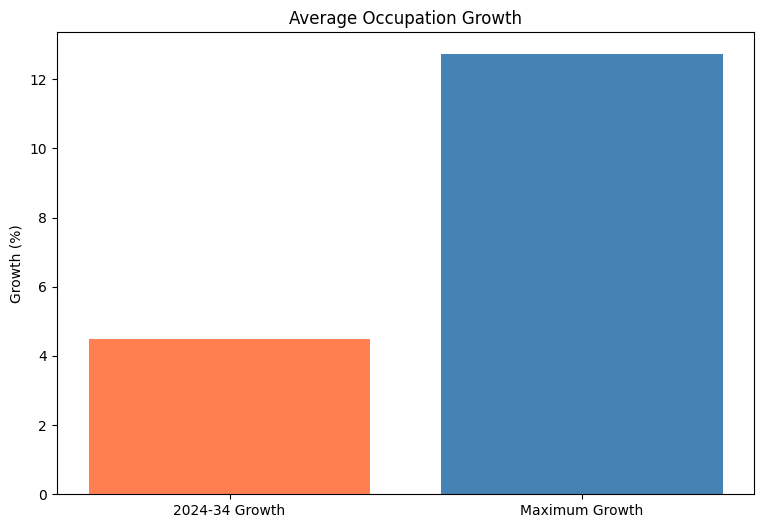

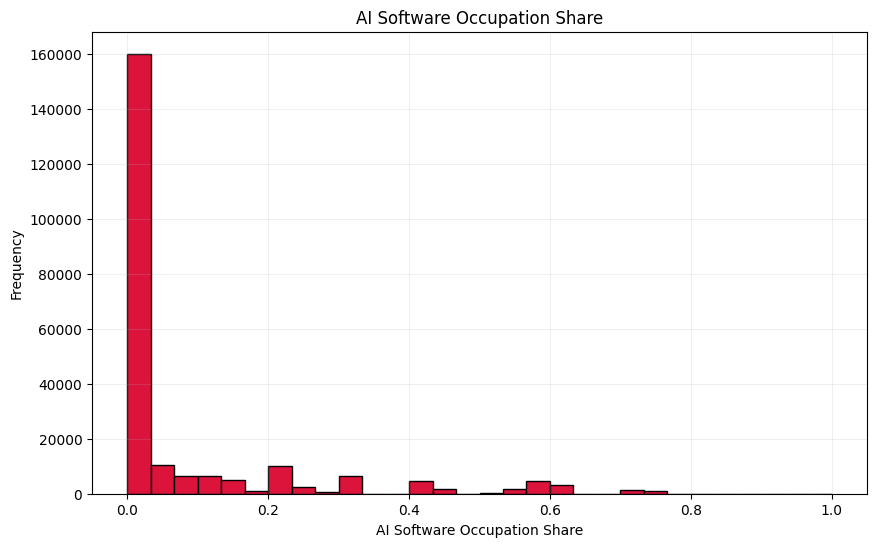

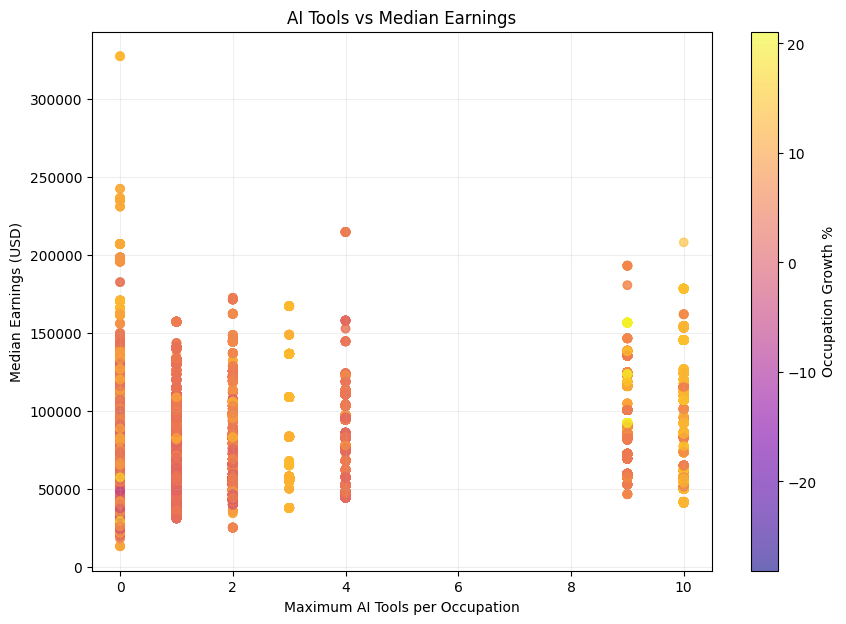

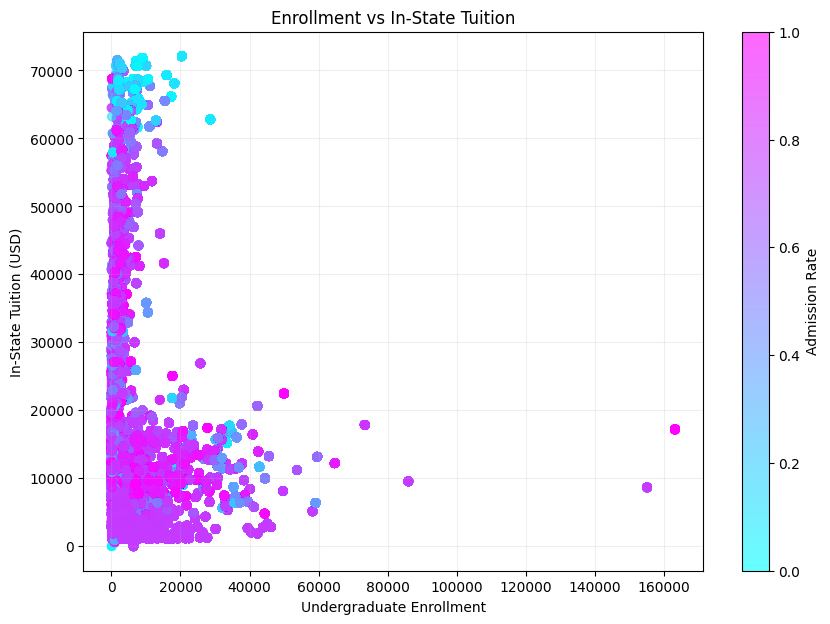

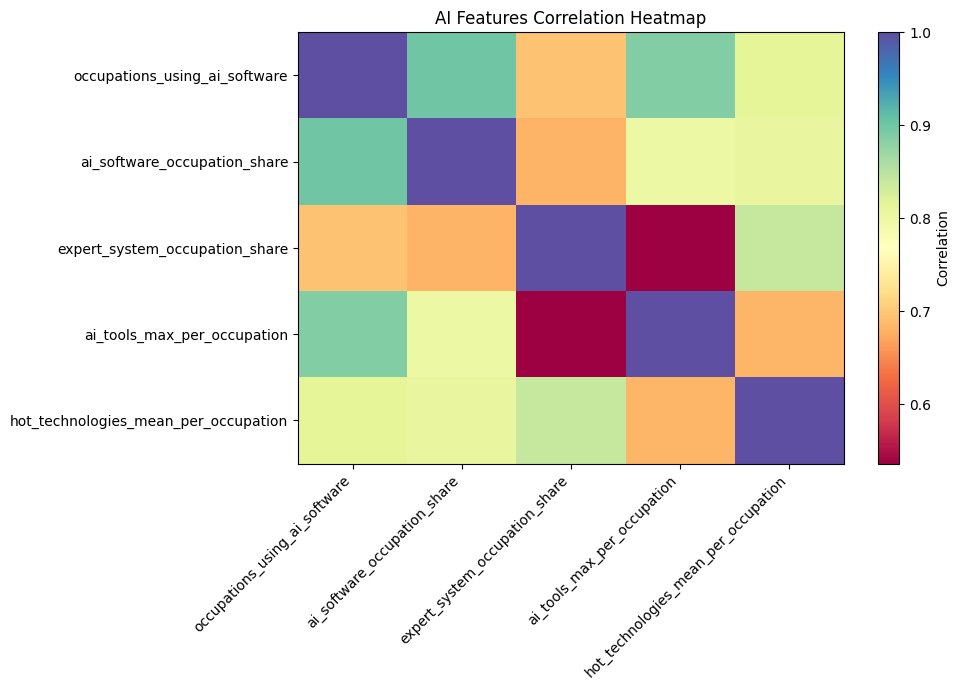

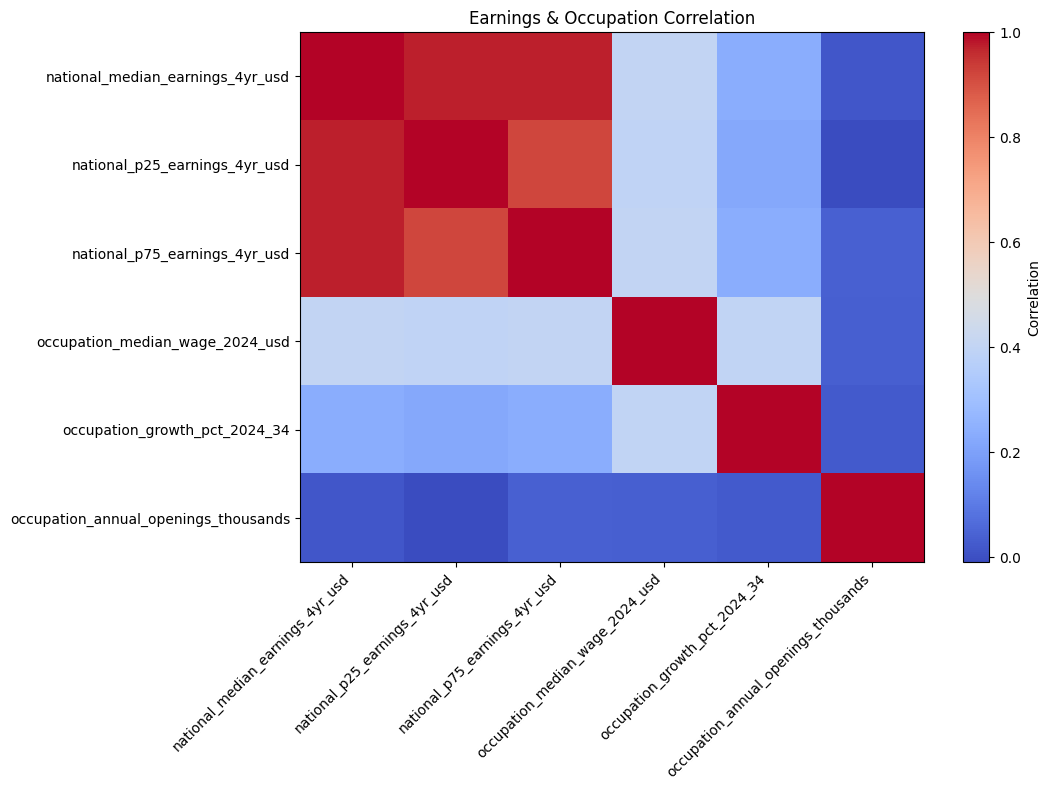

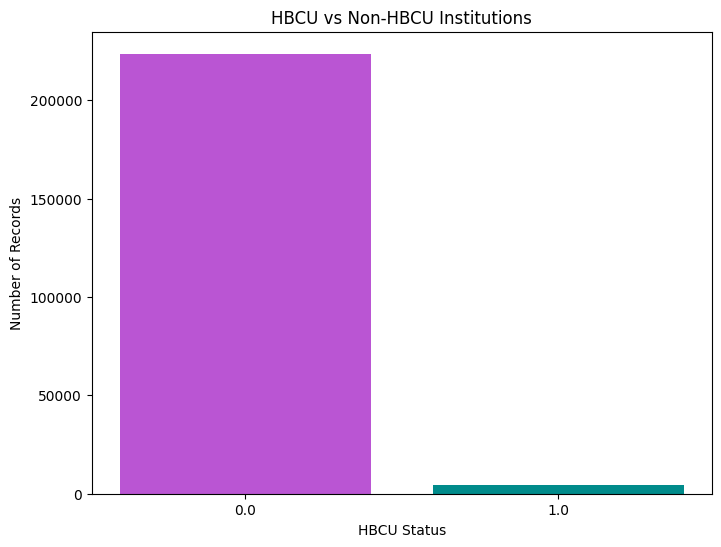


VISUALIZATION COMPLETED SUCCESSFULLY
Rows: 227980
Columns: 50


In [14]:
# ==========================================================
# UNIVERSITY / EDUCATION DATASET VISUALIZATION
# MANY COLORS - COMPLETE CODE
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

# ==========================================================
# NUMERICAL COLUMNS
# ==========================================================

numeric_cols = [
    "institution_latitude",
    "institution_longitude",
    "institution_is_hbcu",
    "institution_admission_rate",
    "institution_undergrad_enrollment",
    "institution_tuition_in_state_usd",
    "institution_tuition_out_state_usd",
    "awards_year1",
    "awards_year2",
    "outcomes_shared_across_campuses",
    "national_median_earnings_4yr_usd",
    "national_p25_earnings_4yr_usd",
    "national_p75_earnings_4yr_usd",
    "not_working_count_5yr",
    "linked_occupations_count",
    "linked_occupations_in_bls",
    "occupation_employment_2024_thousands",
    "occupation_growth_pct_2024_34",
    "occupation_growth_pct_max",
    "occupation_annual_openings_thousands",
    "occupation_median_wage_2024_usd",
    "linked_occupations_in_onet",
    "occupations_using_ai_software",
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation"
]

# Keep only columns that actually exist
numeric_cols = [
    col for col in numeric_cols
    if col in data.columns
]

# ==========================================================
# CONVERT NUMERIC COLUMNS
# ==========================================================

for col in numeric_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

# Fill missing numerical values
for col in numeric_cols:

    data[col] = data[col].fillna(
        data[col].median()
    )

# ==========================================================
# 1. INSTITUTION CONTROL DISTRIBUTION
# ==========================================================

if "institution_control" in data.columns:

    counts = data[
        "institution_control"
    ].value_counts()

    plt.figure(figsize=(10, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.Set1(
            np.linspace(
                0, 1, len(counts)
            )
        )
    )

    plt.title(
        "Institution Control Distribution"
    )

    plt.xlabel("Institution Control")
    plt.ylabel("Number of Records")

    plt.xticks(rotation=45)

    plt.grid(
        axis="y",
        alpha=0.2
    )

    plt.show()

# ==========================================================
# 2. INSTITUTIONS BY REGION
# ==========================================================

if "institution_region" in data.columns:

    counts = (
        data["institution_region"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.viridis(
            np.linspace(
                0, 1, len(counts)
            )
        )
    )

    plt.title(
        "Institutions by Region"
    )

    plt.xlabel("Region")
    plt.ylabel("Number of Institutions")

    plt.xticks(rotation=45)

    plt.show()

# ==========================================================
# 3. TOP INSTITUTION STATES
# ==========================================================

if "institution_state" in data.columns:

    counts = (
        data["institution_state"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(13, 6))

    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.rainbow(
            np.linspace(
                0, 1, len(counts)
            )
        )
    )

    plt.title(
        "Top 15 States by Number of Institutions"
    )

    plt.xlabel("State")
    plt.ylabel("Number of Institutions")

    plt.xticks(rotation=45)

    plt.show()

# ==========================================================
# 4. ADMISSION RATE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    data["institution_admission_rate"].dropna(),
    bins=30,
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Institution Admission Rate Distribution"
)

plt.xlabel("Admission Rate")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 5. TUITION DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    data["institution_tuition_in_state_usd"].dropna(),
    bins=30,
    color="orange",
    edgecolor="black"
)

plt.title(
    "In-State Tuition Distribution"
)

plt.xlabel("Tuition (USD)")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 6. IN-STATE VS OUT-OF-STATE TUITION
# ==========================================================

tuition_data = data[
    [
        "institution_tuition_in_state_usd",
        "institution_tuition_out_state_usd"
    ]
].mean()

plt.figure(figsize=(9, 6))

plt.bar(
    [
        "In-State",
        "Out-of-State"
    ],
    tuition_data.values,
    color=[
        "seagreen",
        "tomato"
    ]
)

plt.title(
    "Average Tuition Comparison"
)

plt.ylabel(
    "Average Tuition (USD)"
)

plt.show()

# ==========================================================
# 7. UNDERGRADUATE ENROLLMENT
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    data[
        "institution_undergrad_enrollment"
    ].dropna(),
    bins=30,
    color="purple",
    edgecolor="black"
)

plt.title(
    "Undergraduate Enrollment Distribution"
)

plt.xlabel("Undergraduate Enrollment")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 8. AWARDS YEAR COMPARISON
# ==========================================================

awards = data[
    [
        "awards_year1",
        "awards_year2"
    ]
].mean()

plt.figure(figsize=(9, 6))

plt.bar(
    [
        "Year 1",
        "Year 2"
    ],
    awards.values,
    color=[
        "dodgerblue",
        "gold"
    ]
)

plt.title(
    "Average Awards by Year"
)

plt.ylabel(
    "Average Awards"
)

plt.show()

# ==========================================================
# 9. NATIONAL EARNINGS DISTRIBUTION
# ==========================================================

earnings = data[
    [
        "national_p25_earnings_4yr_usd",
        "national_median_earnings_4yr_usd",
        "national_p75_earnings_4yr_usd"
    ]
].mean()

plt.figure(figsize=(10, 6))

plt.bar(
    [
        "25th Percentile",
        "Median",
        "75th Percentile"
    ],
    earnings.values,
    color=[
        "lightcoral",
        "mediumseagreen",
        "royalblue"
    ]
)

plt.title(
    "Average National 4-Year Earnings"
)

plt.ylabel(
    "Earnings (USD)"
)

plt.show()

# ==========================================================
# 10. OCCUPATION MEDIAN WAGE
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    data[
        "occupation_median_wage_2024_usd"
    ].dropna(),
    bins=30,
    color="teal",
    edgecolor="black"
)

plt.title(
    "Occupation Median Wage Distribution"
)

plt.xlabel(
    "Median Wage (USD)"
)

plt.ylabel(
    "Frequency"
)

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 11. OCCUPATION GROWTH
# ==========================================================

growth = data[
    [
        "occupation_growth_pct_2024_34",
        "occupation_growth_pct_max"
    ]
].mean()

plt.figure(figsize=(9, 6))

plt.bar(
    [
        "2024-34 Growth",
        "Maximum Growth"
    ],
    growth.values,
    color=[
        "coral",
        "steelblue"
    ]
)

plt.title(
    "Average Occupation Growth"
)

plt.ylabel(
    "Growth (%)"
)

plt.show()

# ==========================================================
# 12. AI SOFTWARE OCCUPATION SHARE
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    data[
        "ai_software_occupation_share"
    ].dropna(),
    bins=30,
    color="crimson",
    edgecolor="black"
)

plt.title(
    "AI Software Occupation Share"
)

plt.xlabel(
    "AI Software Occupation Share"
)

plt.ylabel(
    "Frequency"
)

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 13. AI TOOLS VS EARNINGS
# ==========================================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    data["ai_tools_max_per_occupation"],
    data["national_median_earnings_4yr_usd"],
    c=data["occupation_growth_pct_2024_34"],
    cmap="plasma",
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Occupation Growth %"
)

plt.title(
    "AI Tools vs Median Earnings"
)

plt.xlabel(
    "Maximum AI Tools per Occupation"
)

plt.ylabel(
    "Median Earnings (USD)"
)

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 14. ENROLLMENT VS TUITION
# ==========================================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    data["institution_undergrad_enrollment"],
    data["institution_tuition_in_state_usd"],
    c=data["institution_admission_rate"],
    cmap="cool",
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Admission Rate"
)

plt.title(
    "Enrollment vs In-State Tuition"
)

plt.xlabel(
    "Undergraduate Enrollment"
)

plt.ylabel(
    "In-State Tuition (USD)"
)

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 15. AI FEATURE CORRELATION
# ==========================================================

ai_columns = [
    "occupations_using_ai_software",
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation"
]

ai_columns = [
    col for col in ai_columns
    if col in data.columns
]

if len(ai_columns) > 1:

    corr = data[
        ai_columns
    ].corr()

    plt.figure(figsize=(10, 7))

    plt.imshow(
        corr,
        cmap="Spectral",
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(corr.columns)),
        corr.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(corr.columns)),
        corr.columns
    )

    plt.title(
        "AI Features Correlation Heatmap"
    )

    plt.tight_layout()

    plt.show()

# ==========================================================
# 16. EARNINGS CORRELATION HEATMAP
# ==========================================================

earnings_columns = [
    "national_median_earnings_4yr_usd",
    "national_p25_earnings_4yr_usd",
    "national_p75_earnings_4yr_usd",
    "occupation_median_wage_2024_usd",
    "occupation_growth_pct_2024_34",
    "occupation_annual_openings_thousands"
]

earnings_columns = [
    col for col in earnings_columns
    if col in data.columns
]

corr = data[
    earnings_columns
].corr()

plt.figure(figsize=(11, 8))

plt.imshow(
    corr,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Earnings & Occupation Correlation"
)

plt.tight_layout()

plt.show()

# ==========================================================
# 17. HBCU DISTRIBUTION
# ==========================================================

if "institution_is_hbcu" in data.columns:

    hbcu_counts = (
        data["institution_is_hbcu"]
        .value_counts()
    )

    plt.figure(figsize=(8, 6))

    plt.bar(
        hbcu_counts.index.astype(str),
        hbcu_counts.values,
        color=[
            "mediumorchid",
            "darkcyan"
        ][:len(hbcu_counts)]
    )

    plt.title(
        "HBCU vs Non-HBCU Institutions"
    )

    plt.xlabel(
        "HBCU Status"
    )

    plt.ylabel(
        "Number of Records"
    )

    plt.show()

# ==========================================================
# FINAL MESSAGE
# ==========================================================

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "Rows:",
    data.shape[0]
)

print(
    "Columns:",
    data.shape[1]
)

## Features Engineering

DATASET INFORMATION
Rows    : 227980
Columns : 50

CLASSIFICATION
Number of classes: 2
Classes: ['privacy_suppressed', 'reported']

Training samples: 182384
Testing samples: 45596

CLASSIFICATION ACCURACY
Accuracy: 0.9422
Accuracy (%): 94.22 %

Classification Report:
                    precision    recall  f1-score   support

privacy_suppressed       0.95      0.97      0.96     33974
          reported       0.90      0.86      0.88     11622

          accuracy                           0.94     45596
         macro avg       0.93      0.92      0.92     45596
      weighted avg       0.94      0.94      0.94     45596


Confusion Matrix:
[[32917  1057]
 [ 1578 10044]]

Top Classification Features:
                             Feature  Importance
37               earnings_1yr_status    0.233224
39                       debt_status    0.154169
38               earnings_5yr_status    0.133734
16                      awards_year1    0.078117
17                      awards_year2    0.06

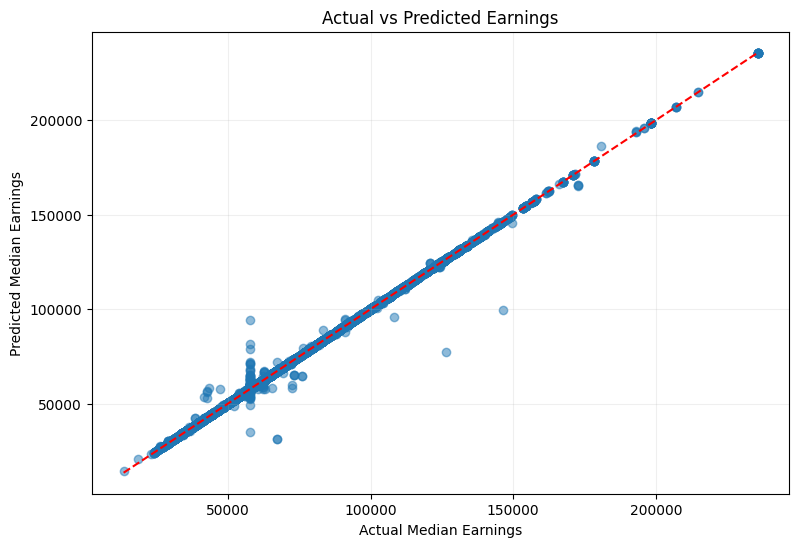


FINAL MODEL SUMMARY
Classification Accuracy : 94.22%
Regression R²           : 0.9992
Regression MAE          : 24.74
Regression RMSE         : 569.07


In [15]:
# ==========================================================
# UNIVERSITY / EDUCATION DATASET
# TRAIN TEST + CLASSIFICATION + REGRESSION
# ACCURACY + R2 + FEATURE ENGINEERING
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

# ==========================================================
# NUMERICAL COLUMNS
# ==========================================================

numeric_columns = [
    "institution_latitude",
    "institution_longitude",
    "institution_is_hbcu",
    "institution_admission_rate",
    "institution_undergrad_enrollment",
    "institution_tuition_in_state_usd",
    "institution_tuition_out_state_usd",
    "awards_year1",
    "awards_year2",
    "outcomes_shared_across_campuses",
    "national_median_earnings_4yr_usd",
    "national_p25_earnings_4yr_usd",
    "national_p75_earnings_4yr_usd",
    "not_working_count_5yr",
    "linked_occupations_count",
    "linked_occupations_in_bls",
    "occupation_employment_2024_thousands",
    "occupation_growth_pct_2024_34",
    "occupation_growth_pct_max",
    "occupation_annual_openings_thousands",
    "occupation_median_wage_2024_usd",
    "linked_occupations_in_onet",
    "occupations_using_ai_software",
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation"
]

numeric_columns = [
    col for col in numeric_columns
    if col in data.columns
]

# ==========================================================
# CONVERT NUMERICAL DATA
# ==========================================================

for col in numeric_columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

# ==========================================================
# HANDLE NUMERICAL NULL VALUES
# ==========================================================

for col in numeric_columns:

    if data[col].isnull().any():

        data[col] = data[col].fillna(
            data[col].median()
        )

# ==========================================================
# CATEGORICAL COLUMNS
# ==========================================================

categorical_columns = data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# ==========================================================
# HANDLE CATEGORICAL NULL VALUES
# ==========================================================

for col in categorical_columns:

    data[col] = data[col].astype(str)

    data[col] = data[col].replace(
        ["nan", "None", ""],
        "Unknown"
    )

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Tuition difference
if (
    "institution_tuition_in_state_usd" in data.columns
    and
    "institution_tuition_out_state_usd" in data.columns
):

    data["tuition_difference"] = (
        data["institution_tuition_out_state_usd"]
        -
        data["institution_tuition_in_state_usd"]
    )

# Average tuition
if (
    "institution_tuition_in_state_usd" in data.columns
    and
    "institution_tuition_out_state_usd" in data.columns
):

    data["average_tuition"] = (
        data["institution_tuition_in_state_usd"]
        +
        data["institution_tuition_out_state_usd"]
    ) / 2

# Earnings range
if (
    "national_p75_earnings_4yr_usd" in data.columns
    and
    "national_p25_earnings_4yr_usd" in data.columns
):

    data["earnings_range"] = (
        data["national_p75_earnings_4yr_usd"]
        -
        data["national_p25_earnings_4yr_usd"]
    )

# AI activity score
ai_features = [
    "occupations_using_ai_software",
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation"
]

available_ai_features = [
    col for col in ai_features
    if col in data.columns
]

if len(available_ai_features) > 0:

    data["ai_activity_score"] = (
        data[available_ai_features]
        .mean(axis=1)
    )

# Occupation opportunity score
occupation_features = [
    "occupation_growth_pct_2024_34",
    "occupation_annual_openings_thousands",
    "occupation_median_wage_2024_usd"
]

available_occupation_features = [
    col for col in occupation_features
    if col in data.columns
]

if len(available_occupation_features) > 0:

    data["occupation_opportunity_score"] = (
        data[available_occupation_features]
        .rank(pct=True)
        .mean(axis=1)
    )

# ==========================================================
# ==========================================================
# CLASSIFICATION
# TARGET = earnings_4yr_status
# ==========================================================
# ==========================================================

print("\n" + "=" * 70)
print("CLASSIFICATION")
print("=" * 70)

classification_target = "earnings_4yr_status"

if classification_target not in data.columns:

    raise ValueError(
        "Classification target not found: "
        + classification_target
    )

# Remove rows where target is missing
classification_data = data[
    data[classification_target].notna()
].copy()

X_class = classification_data.drop(
    columns=[classification_target]
)

y_class = classification_data[
    classification_target
].astype(str)

# ==========================================================
# REMOVE IDENTIFIER / HIGH-CARDINALITY COLUMNS
# ==========================================================

columns_to_remove = [
    "program_id",
    "unitid",
    "opeid6",
    "institution_name",
    "cip_title",
    "cip_family_title",
    "credential_name",
    "largest_linked_occupation",
    "largest_linked_occupation_soc"
]

X_class.drop(
    columns=columns_to_remove,
    inplace=True,
    errors="ignore"
)

# ==========================================================
# LABEL ENCODING
# ==========================================================

class_encoders = {}

categorical_features = X_class.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_features:

    encoder = LabelEncoder()

    X_class[col] = encoder.fit_transform(
        X_class[col].astype(str)
    )

    class_encoders[col] = encoder

# ==========================================================
# TARGET ENCODING
# ==========================================================

target_encoder = LabelEncoder()

y_class_encoded = target_encoder.fit_transform(
    y_class
)

print(
    "Number of classes:",
    len(target_encoder.classes_)
)

print(
    "Classes:",
    list(target_encoder.classes_)
)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

class_counts = pd.Series(
    y_class_encoded
).value_counts()

if class_counts.min() >= 2:

    X_train_class, X_test_class, \
    y_train_class, y_test_class = train_test_split(
        X_class,
        y_class_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_class_encoded
    )

else:

    X_train_class, X_test_class, \
    y_train_class, y_test_class = train_test_split(
        X_class,
        y_class_encoded,
        test_size=0.20,
        random_state=42
    )

print("\nTraining samples:",
      X_train_class.shape[0])

print("Testing samples:",
      X_test_class.shape[0])

# ==========================================================
# RANDOM FOREST CLASSIFIER
# ==========================================================

classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

classifier.fit(
    X_train_class,
    y_train_class
)

# ==========================================================
# CLASSIFICATION PREDICTION
# ==========================================================

y_pred_class = classifier.predict(
    X_test_class
)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

print("\n" + "=" * 50)
print("CLASSIFICATION ACCURACY")
print("=" * 50)

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Accuracy (%):",
    round(accuracy * 100, 2),
    "%"
)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test_class,
        y_pred_class,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_class,
        y_pred_class
    )
)

# ==========================================================
# CLASSIFICATION FEATURE IMPORTANCE
# ==========================================================

classification_importance = pd.DataFrame({

    "Feature": X_train_class.columns,

    "Importance":
        classifier.feature_importances_

})

classification_importance = (
    classification_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("\nTop Classification Features:")

print(
    classification_importance.head(15)
)

# ==========================================================
# ==========================================================
# REGRESSION
# TARGET = national_median_earnings_4yr_usd
# ==========================================================
# ==========================================================

print("\n" + "=" * 70)
print("REGRESSION")
print("=" * 70)

regression_target = (
    "national_median_earnings_4yr_usd"
)

if regression_target not in data.columns:

    raise ValueError(
        "Regression target not found: "
        + regression_target
    )

# ==========================================================
# REMOVE ROWS WITH MISSING TARGET
# ==========================================================

regression_data = data[
    data[regression_target].notna()
].copy()

X_reg = regression_data.drop(
    columns=[regression_target]
)

y_reg = regression_data[
    regression_target
]

# ==========================================================
# REMOVE IDENTIFIERS
# ==========================================================

X_reg.drop(
    columns=columns_to_remove,
    inplace=True,
    errors="ignore"
)

# ==========================================================
# LABEL ENCODING
# ==========================================================

reg_encoders = {}

categorical_reg = X_reg.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_reg:

    encoder = LabelEncoder()

    X_reg[col] = encoder.fit_transform(
        X_reg[col].astype(str)
    )

    reg_encoders[col] = encoder

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train_reg, X_test_reg, \
y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print(
    "\nTraining samples:",
    X_train_reg.shape[0]
)

print(
    "Testing samples:",
    X_test_reg.shape[0]
)

# ==========================================================
# RANDOM FOREST REGRESSOR
# ==========================================================

regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

regressor.fit(
    X_train_reg,
    y_train_reg
)

# ==========================================================
# REGRESSION PREDICTION
# ==========================================================

y_pred_reg = regressor.predict(
    X_test_reg
)

# ==========================================================
# R2 SCORE
# ==========================================================

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

# ==========================================================
# MAE
# ==========================================================

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

# ==========================================================
# RMSE
# ==========================================================

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

print("\n" + "=" * 50)
print("REGRESSION RESULTS")
print("=" * 50)

print(
    "R² Score:",
    round(r2, 4)
)

print(
    "MAE:",
    round(mae, 2)
)

print(
    "RMSE:",
    round(rmse, 2)
)

# ==========================================================
# REGRESSION FEATURE IMPORTANCE
# ==========================================================

regression_importance = pd.DataFrame({

    "Feature": X_train_reg.columns,

    "Importance":
        regressor.feature_importances_

})

regression_importance = (
    regression_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("\nTop Regression Features:")

print(
    regression_importance.head(15)
)

# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

min_value = min(
    y_test_reg.min(),
    y_pred_reg.min()
)

max_value = max(
    y_test_reg.max(),
    y_pred_reg.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--"
)

plt.xlabel(
    "Actual Median Earnings"
)

plt.ylabel(
    "Predicted Median Earnings"
)

plt.title(
    "Actual vs Predicted Earnings"
)

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(
    f"Classification Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Regression R²           : {r2:.4f}"
)

print(
    f"Regression MAE          : {mae:.2f}"
)

print(
    f"Regression RMSE         : {rmse:.2f}"
)

## Thanks...........Please Upvote